# Detail-Auswertung

## Imports and constants

In [1]:
# Imports / global contants

# csv Dateien sind im Verzeichnis ../data zu finden

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib import figure
import math
import numpy as np
import seaborn as sns
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks
import gc
import pylab

from pandas.plotting import parallel_coordinates

%matplotlib inline

timeFormat = "%Y-%m-%dT%H:%M:%S.%fZ"

export = "../export/"
export_img = "../export/img/"
export_interactions = "../export/interaction/"

path = "../data/"

---
## Function: Extract Interactions from cleaned data

* removes all logs before the start of the trial and after it has ended with completed / failed / terminated state
* saved to `export/cleanedStudy_interactionOnly.csv`
* stored in `df_cleaned`


---

In [2]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy.csv', sep=";")

# retrieve labels for results
states = df_cleaned[
    ((df_cleaned["posX"] == " COMPLETED") | 
    (df_cleaned["posX"] == " FAILED") | 
    (df_cleaned["posX"] == " TERMINATED") | 
    (df_cleaned["posX"] == " START"))
  ]

# insert labels
df_cleaned["Result"] = states["posX"]

# fill (bottom-up)
df_cleaned["Result"].fillna(method='bfill', inplace=True)

# drop na (end)
df_cleaned = df_cleaned.dropna(subset=["Result"])

# drop start (between trials)
df_cleaned = df_cleaned.drop(df_cleaned[(df_cleaned["Result"] == " START") & (df_cleaned["posX"] != " START")].index)

df_cleaned["Block"] = (df_cleaned["TaskNo"] / 18).apply(np.ceil).astype(int)
df_cleaned["TaskNo"] = (df_cleaned["TaskNo"] - ((df_cleaned["Block"] - 1) * 18)).astype(int)
df_cleaned["TrialIdx"] = df_cleaned["TrialIdx"].astype(int)   
df_cleaned["TargetLayers"] = df_cleaned["TargetLayers"].str.split(",")
df_cleaned["Target"] = df_cleaned.apply(lambda item: item["TargetLayers"][item["TrialIdx"]], axis = 1).astype(int)
df_cleaned["Target_Relative"] = df_cleaned["Target"].astype(float) / df_cleaned["LayerCount"].astype(float)

df_cleaned.reset_index(inplace=True)

df_cleaned.rename(columns={ df_cleaned.columns[0]:"SampleIdx_global", df_cleaned.columns[1]:"SampleIdx_Proband", "TrialIdx":"Trial", "LayerCount":"NumLayers", "TaskNo":"Task" }, inplace=True)

display(df_cleaned)

df_cleaned.to_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep= ";")



,SampleIdx_global,SampleIdx_Proband,DateTime,State,mappingMethod,Task,TargetLayers,NumLayers,Trial,posX,...,posZ,TimeStamp,iteractionType,currentLayer,Proband,shifted,Result,Block,Target,Target_Relative
0,135,135,2021-05-10T12:13:56.584Z,VIEW,direct,1,"[4, 5, 3, 1, 2]",6,0,START,...,NaN,NaN,NaN,NaN,1,1.0,START,1,4,0.666667
1,136,136,2021-05-10T12:13:56.602Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,2,1,1.0,COMPLETED,1,4,0.666667
2,137,137,2021-05-10T12:13:56.633Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,2,1,1.0,COMPLETED,1,4,0.666667
3,138,138,2021-05-10T12:13:56.676Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,-,1,1.0,COMPLETED,1,4,0.666667
4,139,139,2021-05-10T12:13:56.697Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,-,1,1.0,COMPLETED,1,4,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535230,2360983,90204,2021-06-30T12:37:15.245Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.252979726,...,-0.9999999,637606606352421800,1,6,24,54.0,FAILED,3,1,0.166667
1535231,2360984,90205,2021-06-30T12:37:15.291Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.231738284,...,-0.9999999,637606606352861800,1,6,24,54.0,FAILED,3,1,0.166667
1535232,2360985,90206,2021-06-30T12:37:15.323Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.231738284,...,-0.9999999,637606606353161900,1,6,24,54.0,FAILED,3,1,0.166667
1535233,2360986,90207,2021-06-30T12:37:15.361Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.240411818,...,-0.9999999,637606606353551700,1,6,24,54.0,FAILED,3,1,0.166667


---
## Function: extract layer borders

`getLayerBorders(layers, mapping)`

---

In [3]:
def getLayerBorders(layers, mapping):
    layerdata = pd.read_csv(rf'{path}meta/depthlayers.csv', sep=";")

    layer = layerdata[(layerdata.iloc[:,0] == layers) & (layerdata.iloc[:, 1] == mapping)]

    return np.array(layer.iloc[:,3].str.split("|").iloc[0], float)

---
## Function: Draw Graph for a single Trial

`drawSingleInteractionGraph(proband, block, task, trial, show=False)`

---

In [4]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep=";")

# proband = 24
# task = 18
# block = 3
# trial = 3

def drawSingleInteractionGraph(proband, block, task, trial, show=False):

    exp_data = df_cleaned[(df_cleaned["Proband"] == proband) & (df_cleaned["Task"] == task) & (df_cleaned["Block"] == block) & (df_cleaned["Trial"] == trial)].reset_index(drop=True)

    z_data = exp_data["posZ"].replace("-", 0).astype(float)

    target = exp_data["Target"][0]
    num_layers = exp_data["NumLayers"][0]
    mapping = exp_data["mappingMethod"][0]

    borders = getLayerBorders(num_layers, mapping)

    miny = [-borders[target+1]]*len(z_data)
    maxy = [-borders[target]]*len(z_data)

    hold = exp_data[exp_data["posX"] == " HOLD"].index

    ex_max, _ = find_peaks(z_data, prominence=0.05)
    ex_min, _ = find_peaks(-z_data, prominence=0.05)

    peaks = np.concatenate([ex_max,ex_min])

    fig,ax = plt.subplots(1, 1, tight_layout=True, figsize=(25,8), clear=True)

    ax.plot(exp_data.index, z_data, label='Depth')
    ax.plot(peaks, z_data[peaks], "o")

    plt.vlines(x= hold, ymin=-1, ymax=0, linestyles="--")

    ax.plot(miny, linestyle=":")
    ax.plot(maxy, linestyle=":")
    
    plt.suptitle(f'Proband {proband}: Block {block} | Task {task} | Trial {trial}',fontsize=20, y=1)
    plt.title(f'{num_layers} Layers ({mapping}) | Target: {target}',fontsize=16)

    plt.savefig(rf'{export_interactions}single/Interaction_p{proband}_{block}_{task}_{trial}.jpg')
    plt.savefig(rf'{export_interactions}single/Interaction_p{proband}_{block}_{task}_{trial}.svg')

    if show:
        plt.show()
    else:   
        plt.close(fig)          

---
## Function: Draw Graph for specific configuration

`drawInteractionGraph(num_layers, target, mapping, show=False)`

---

In [10]:
def drawInteractionGraph(num_layers, target, mapping, show=False):

   exp_data_complete = df_cleaned[(df_cleaned["mappingMethod"] == mapping) & (df_cleaned["Target"] == target) & (df_cleaned["NumLayers"] == num_layers)].reset_index(drop=True).groupby(["Proband", "Task", "Block", "Trial"])

   borders = getLayerBorders(num_layers, mapping)

   fig,ax = plt.subplots(1, 1, tight_layout=True, figsize=(25,8), clear=True)

   z_data = pd.DataFrame()
   peaks = pd.DataFrame()
   hold = []

   for name, group in exp_data_complete:

      norm = group.reset_index(drop=True)

      newData = norm["posZ"].replace("-", 0).astype(float)
      z_data = pd.concat([z_data, newData], axis=1, ignore_index=True)

      ax.plot(newData.index, newData, label=name)

      ex_max, _ = find_peaks(newData, prominence=0.05)
      ex_min, _ = find_peaks(-newData, prominence=0.05)

      newPeaks = np.concatenate([ex_max,ex_min])
      peaks = pd.concat([peaks, pd.DataFrame(newPeaks)], axis=1, ignore_index=True)
      
      ax.plot(newPeaks, newData[newPeaks], "o")

      newHold = np.array(norm[norm["posX"] == " HOLD"].index)

      hold = np.concatenate([hold, newHold])

   plt.vlines(x= hold, ymin=-1, ymax=0, linestyles="--")

   miny = [-borders[target+1]]*len(z_data)
   maxy = [-borders[target]]*len(z_data)

   ax.plot(miny, linestyle=":")
   ax.plot(maxy, linestyle=":")

   plt.suptitle(f'{num_layers} Layers ({mapping}) | Target: {target}',fontsize=20, y=1)

   plt.savefig(rf'{export_interactions}allInteractions_{target}-{num_layers}_{mapping}.jpg')
   plt.savefig(rf'{export_interactions}allInteractions_{target}-{num_layers}_{mapping}.svg')
     
   if show:
      plt.show()
   else:
      plt.close(fig)

---
## Draw __ALL__ interaction graphs per configuration (Layers/Target/MappingMethod)

generate and save images as .jpg and .csv (png not working: axes are not correctly exported)

---

In [ ]:
# num layers
all_layers = [6,9,12,15,18,21]

# mapping
mappings = [" direct", " densening", " widening"]

plt.ioff()
plt.close('all')

for num in all_layers:
    all_targets = np.array(df_cleaned[df_cleaned["NumLayers"] == num]["Target"].drop_duplicates().sort_values())
    gc.collect()
    print(f'plotting config for {num} layers')
    for target in all_targets:
        for map in mappings:
            drawInteractionGraph(num, target, map)

plt.ion()

---
## Draw __ALL__ Single Interaction Graphs

generate and save images as .jpg and .csv (png not working: axes are not correctly exported)

---

In [ ]:
all_probands = np.array(df_cleaned["Proband"].drop_duplicates().sort_values())
all_blocks = np.array(df_cleaned["Block"].drop_duplicates().sort_values())
all_tasks = np.array(df_cleaned["Task"].drop_duplicates().sort_values())
all_trials = np.array(df_cleaned["Trial"].drop_duplicates().sort_values())

print(f'Starting to plot all single graphs for {len(all_probands)} Probands')
plt.ioff()
plt.close('all')

for p in all_probands:
    gc.collect()    
    for b in all_blocks:       
        for t in all_tasks:
            for tr in all_trials:
                drawSingleInteractionGraph(p,b,t,tr)
    print(f'Finished Proband {p}')  

plt.ion()

--- 
## Function: Statistics for peaks

| NumLayers | MappingMethod | TargetLayer | Peaks_Z           | Peaks_total | Peaks_lower  | Peaks_inside | Peaks_deeper| Peaks_before_hold | Peaks_after_hold | Result    |
| --------- | ------------- | ----------- | ----------------- | ----------- | ------------ | ------------ | ----------- | ------------------| ---------------- | --------- | 
| 21        | direct        | 6           | [-0.1, -0.5, ...] | 6           | 3            | 1            | 2           | 6                 | 0                | COMPLETED |

---

In [63]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep=";")

def extractAllPeaks(num_layers, mapping, target):
   exp_data_complete = df_cleaned[(df_cleaned["mappingMethod"] == mapping) & (df_cleaned["Target"] == target) & (df_cleaned["NumLayers"] == num_layers)].reset_index(drop=True).groupby(["Proband", "Task", "Block", "Trial"])

   borders = getLayerBorders(num_layers, mapping)

   complete = pd.DataFrame()

   for name, group in exp_data_complete:
      
      result = pd.DataFrame()      

      norm = group.reset_index(drop=True)

      z_data = np.array(norm["posZ"].replace("-", 0).astype(float), float)  

      ex_max, _ = find_peaks(z_data, prominence=0.05)
      ex_min, _ = find_peaks(-z_data, prominence=0.05)
      
      peaks = []
      # if len(ex_min) + len(ex_max) > 0:
      peaks = np.concatenate([ex_max,ex_min])

      pos = norm[norm["posX"] == " HOLD"]
      
      if len(pos) == 1:
         hold = np.array(pos.index)

      else: #hold.isnull():
         hold = np.array(norm.index[-1])

      peaks_z = pd.DataFrame(pd.DataFrame(peaks).apply(lambda item: norm.iloc[item.index]["posZ"])[0].replace(to_replace='-', value='0').astype(float).fillna(0))
           
      result["Peaks_Z"] = [peaks_z[0].values]
      result["Peaks_Total"] = len(peaks)

      result["Result"] = norm["Result"][1]

      result["HOLD_idx"] = [hold]

      before = peaks[peaks >= hold]
      after = peaks[peaks < hold]

      result["Peaks_AfterHold"] = len(before)
      result["Peaks_AfterHold_Values"] = [before]
      result["Peaks_BeforeHold"] = len(after)
      result["Peaks_BeforeHold_Values"] = [after]

      lower = peaks_z[peaks_z[0] > -borders[target]]
      deeper = peaks_z[peaks_z[0] < -borders[target+1]]

      result["Peaks_lower"] = len(lower)
      result["Peaks_lower_Values"] = [lower[0].values]
      result["Peaks_deeper"] = len(deeper)
      result["Peaks_deeper_Values"] = [deeper[0].values]

      result["Peaks_between"] = result["Peaks_Total"] - (result["Peaks_lower"] + result["Peaks_deeper"])

      result["Peaks_Z"] = result["Peaks_Z"]
      
      complete = pd.concat([complete, result])
   

   complete["NumLayers"] = num_layers
   complete["MappingMethod"] = mapping
   complete["TargetLayer"] = target
   complete["TargetLayer_Relative"] = target / num_layers
   complete["TargetDepth"] = -0.5 * (borders[target] + borders[target+1])

   return complete
   
# test
peaks_df = extractAllPeaks(6, " densening", 1)
display(peaks_df)

,Peaks_Z,Peaks_Total,Result,HOLD_idx,Peaks_AfterHold,Peaks_AfterHold_Values,Peaks_BeforeHold,Peaks_BeforeHold_Values,Peaks_lower,Peaks_lower_Values,Peaks_deeper,Peaks_deeper_Values,Peaks_between,NumLayers,MappingMethod,TargetLayer,TargetLayer_Relative,TargetDepth
0,"[0.0, -0.228947267]",2,TERMINATED,[114],0,[],2,"[14, 51]",1,[0.0],0,[],1,6,densening,1,0.166667,-0.31605
0,"[0.0, -0.509210467]",2,COMPLETED,[101],0,[],2,"[12, 47]",1,[0.0],1,[-0.509210467],0,6,densening,1,0.166667,-0.31605
0,"[0.0, -0.552631557, -0.378947318]",3,TERMINATED,[70],0,[],3,"[13, 46, 50]",1,[0.0],1,[-0.552631557],1,6,densening,1,0.166667,-0.31605
0,[0.0],1,TERMINATED,[70],0,[],1,[18],1,[0.0],0,[],0,6,densening,1,0.166667,-0.31605
0,"[0.0, -0.5644736]",2,COMPLETED,[96],0,[],2,"[15, 46]",1,[0.0],1,[-0.5644736],0,6,densening,1,0.166667,-0.31605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,[0.0],1,COMPLETED,[102],0,[],1,[22],1,[0.0],0,[],0,6,densening,1,0.166667,-0.31605
0,"[0.0, -0.7499999]",2,COMPLETED,[94],0,[],2,"[19, 54]",1,[0.0],1,[-0.7499999],0,6,densening,1,0.166667,-0.31605
0,"[0.0, -0.256578863, -0.307894677]",3,COMPLETED,[99],0,[],3,"[27, 10, 57]",1,[0.0],0,[],2,6,densening,1,0.166667,-0.31605
0,"[0.0, -0.0828946456]",2,COMPLETED,[67],0,[],2,"[4, 18]",2,"[0.0, -0.0828946456]",0,[],0,6,densening,1,0.166667,-0.31605


---

## Function: save peaks to file

* correct serialization of cells containing numpy arrays using `np.array2string`
* saved to `export/all_peaks.csv'`

---

In [50]:
def savePeaks(result_all):
    # need to extra format floating point lists as pandas serialization does not like them
    result_all["Peaks_Z"] = result_all["Peaks_Z"].apply(lambda item: np.array2string(item, separator="|"))
    result_all["Peaks_lower_Values"] = result_all["Peaks_lower_Values"].apply(lambda item: np.array2string(item, separator="|"))
    result_all["Peaks_deeper_Values"] = result_all["Peaks_deeper_Values"].apply(lambda item: np.array2string(item, separator="|"))

    result_all.to_csv(rf'{export}all_peaks.csv', sep= ";")

---

## Function: load peaks from file

* correct deserialization of cells containing numpy arrays using `np.fromstring`
* load from `export/all_peaks.csv'`

---

In [15]:
def loadPeaks():
    result = pd.read_csv(rf'{export}all_peaks.csv', sep= ";")

    # when importing: convert back to pandas arrays
    result["Peaks_Z"] = result["Peaks_Z"].apply(lambda item: np.fromstring(item.replace('[','').replace(']',''), dtype=float, sep="|"))
    result["Peaks_lower_Values"] = result["Peaks_lower_Values"].apply(lambda item: np.fromstring(item.replace('[','').replace(']',''), dtype=float, sep="|"))
    result["Peaks_deeper_Values"] = result["Peaks_deeper_Values"].apply(lambda item: np.fromstring(item.replace('[','').replace(']',''), dtype=float, sep="|")) 

    return result

---

## Iterate over all configurations (NumLayers / MappingMethod / Targets) to extract all peaks

saved to `export\all_peaks.csv`

---

In [64]:
all_layers = np.array(df_cleaned["NumLayers"].drop_duplicates().sort_values())
all_mappings = np.array(df_cleaned["mappingMethod"].drop_duplicates().sort_values())

result_all = pd.DataFrame()

for l in all_layers:  
    for m in all_mappings:
        all_targets = np.array(df_cleaned[(df_cleaned["NumLayers"] == l) & (df_cleaned["mappingMethod"] == m)]["Target"].drop_duplicates().sort_values())
        print(f'{l} layers [{m}] - targets: {all_targets}')
        for t in all_targets:
            # print(f'{l}, {m}, {t}')
            p = extractAllPeaks(l, m, t)            
            result_all = pd.concat([result_all, p])

savePeaks(result_all)

6 layers [ densening] - targets: [1 2 3 4 5]
6 layers [ direct] - targets: [1 2 3 4 5]
6 layers [ widening] - targets: [1 2 3 4 5]
9 layers [ densening] - targets: [1 2 5 7 8]
9 layers [ direct] - targets: [1 2 5 7 8]
9 layers [ widening] - targets: [1 2 5 7 8]
12 layers [ densening] - targets: [ 1  3  6  9 11]
12 layers [ direct] - targets: [ 1  3  6  9 11]
12 layers [ widening] - targets: [ 1  3  6  9 11]
15 layers [ densening] - targets: [ 1  4  8 11 14]
15 layers [ direct] - targets: [ 1  4  8 11 14]
15 layers [ widening] - targets: [ 1  4  8 11 14]
18 layers [ densening] - targets: [ 1  5  9 14 17]
18 layers [ direct] - targets: [ 1  5  9 14 17]
18 layers [ widening] - targets: [ 1  5  9 14 17]
21 layers [ densening] - targets: [ 1  5 11 16 20]
21 layers [ direct] - targets: [ 1  5 11 16 20]
21 layers [ widening] - targets: [ 1  5 11 16 20]


--- 

## Draw Graph for peaks statistics

---

NumLayers Peaks_Total                                      Peaks_lower  \
                    sum count      mean       std        var         sum   
0         6        1891  1035  1.827053  1.946092   3.787275        1455   
1         9        2290  1035  2.212560  2.022417   4.090171        1729   
2        12        2822  1035  2.726570  2.648239   7.013171        2192   
3        15        3397  1035  3.282126  3.373239  11.378742        2634   
4        18        3714  1035  3.588406  3.859809  14.898125        2921   
5        21        4031  1035  3.894686  4.562644  20.817718        3114   

                             ... Peaks_deeper                            \
  count      mean       std  ...          sum count      mean       std   
0  1035  1.405797  1.573341  ...          281  1035  0.271498  1.020443   
1  1035  1.670531  1.651051  ...          451  1035  0.435749  1.162967   
2  1035  2.117874  2.365455  ...          517  1035  0.499517  1.239560   
3  1035  2.544928  3.003006  ...          654  1035  0.631884  1.553292   
4  1035  2.822222  3.402310  ...          668  1035  0.645411  1.620966   
5  1035  3.008696  3.711934  ...          805  1035  0.777778  2.041847   

            Peaks_between                                      
        var           sum count      mean       std       var  
0  1.041305           155  1035  0.149758  0.505088  0.255114  
1  1.352493           110  1035  0.106280  0.410582  0.168578  
2  1.536508           113  1035  0.109179  0.440528  0.194065  
3  2.412715           109  1035  0.105314  0.404903  0.163947  
4  2.627530           125  1035  0.120773  0.501355  0.251357  
5  4.169138           112  1035  0.108213  0.491593  0.241664  

[6 rows x 21 columns]

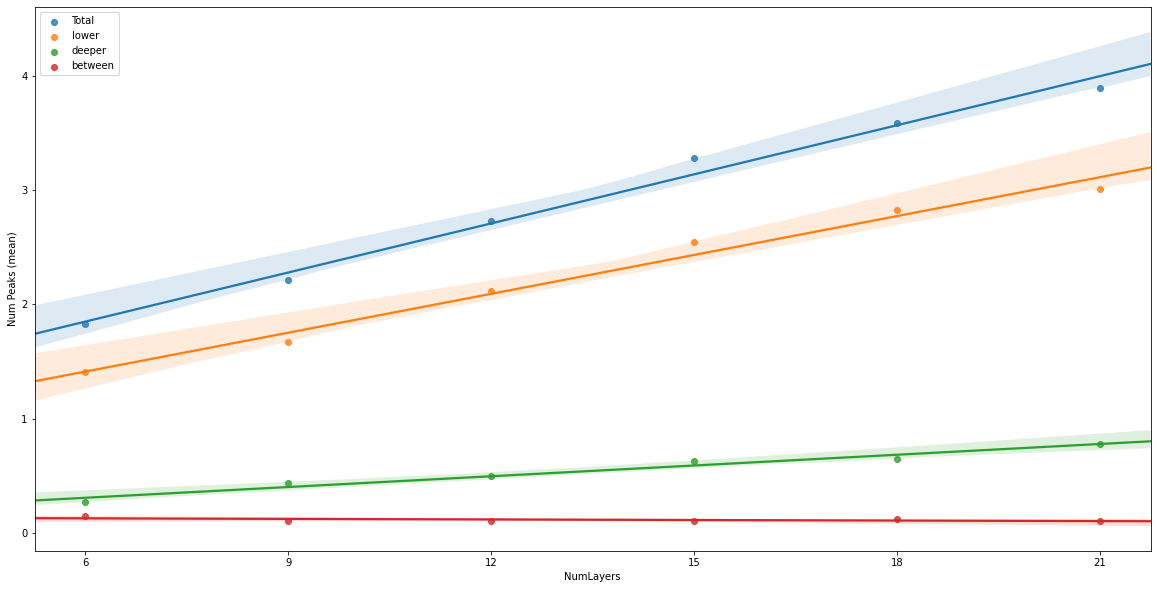

MappingMethod NumLayers Peaks_Total                                       \
                                   sum count      mean       std        var   
0      densening         6         656   345  1.901449  2.043601   4.176306   
1      densening         9         783   345  2.269565  1.763594   3.110263   
2      densening        12         905   345  2.623188  1.894771   3.590158   
3      densening        15        1135   345  3.289855  2.899987   8.409926   
4      densening        18        1336   345  3.872464  3.872378  14.995315   
5      densening        21        1358   345  3.936232  3.684741  13.577317   
6         direct         6         613   345  1.776812  1.927324   3.714577   
7         direct         9         758   345  2.197101  1.950400   3.804061   
8         direct        12         983   345  2.849275  3.059565   9.360937   
9         direct        15        1142   345  3.310145  3.268869  10.685507   
10        direct        18        1207   345  3.498551  3.861049  14.907701   
11        direct        21        1311   345  3.800000  4.702548  22.113953   
12      widening         6         622   345  1.802899  1.866626   3.484294   
13      widening         9         749   345  2.171014  2.318348   5.374739   
14      widening        12         934   345  2.707246  2.846577   8.103000   
15      widening        15        1120   345  3.246377  3.886492  15.104820   
16      widening        18        1171   345  3.394203  3.840720  14.751129   
17      widening        21        1362   345  3.947826  5.183567  26.869363   

   Peaks_lower                  ... Peaks_deeper                            \
           sum count      mean  ...          sum count      mean       std   
0          564   345  1.634783  ...           37   345  0.107246  0.428056   
1          652   345  1.889855  ...           88   345  0.255072  0.676760   
2          740   345  2.144928  ...          132   345  0.382609  1.036395   
3          938   345  2.718841  ...          169   345  0.489855  1.492437   
4         1132   345  3.281159  ...          163   345  0.472464  1.136074   
5         1137   345  3.295652  ...          171   345  0.495652  1.193787   
6          451   345  1.307246  ...          102   345  0.295652  1.275716   
7          559   345  1.620290  ...          160   345  0.463768  1.243351   
8          765   345  2.217391  ...          184   345  0.533333  1.387094   
9          861   345  2.495652  ...          235   345  0.681159  1.574624   
10         949   345  2.750725  ...          212   345  0.614493  1.418039   
11        1008   345  2.921739  ...          273   345  0.791304  2.439366   
12         440   345  1.275362  ...          142   345  0.411594  1.127811   
13         518   345  1.501449  ...          203   345  0.588406  1.415809   
14         687   345  1.991304  ...          201   345  0.582609  1.264331   
15         835   345  2.420290  ...          250   345  0.724638  1.585582   
16         840   345  2.434783  ...          293   345  0.849275  2.126906   
17         969   345  2.808696  ...          361   345  1.046377  2.236886   

             Peaks_between                                      
         var           sum count      mean       std       var  
0   0.183232            55   345  0.159420  0.560917  0.314628  
1   0.458005            43   345  0.124638  0.436824  0.190816  
2   1.074115            33   345  0.095652  0.402909  0.162336  
3   2.227368            28   345  0.081159  0.348283  0.121301  
4   1.290664            41   345  0.118841  0.470426  0.221301  
5   1.425126            50   345  0.144928  0.648687  0.420795  
6   1.627452            60   345  0.173913  0.527073  0.277806  
7   1.545922            39   345  0.113043  0.433319  0.187765  
8   1.924031            34   345  0.098551  0.376062  0.141422  
9   2.479441            46   345  0.133333  0.463388  0.214729  
10  2.010836            46   345  0.133333  0.516773  0.267054  
11  5.950506    

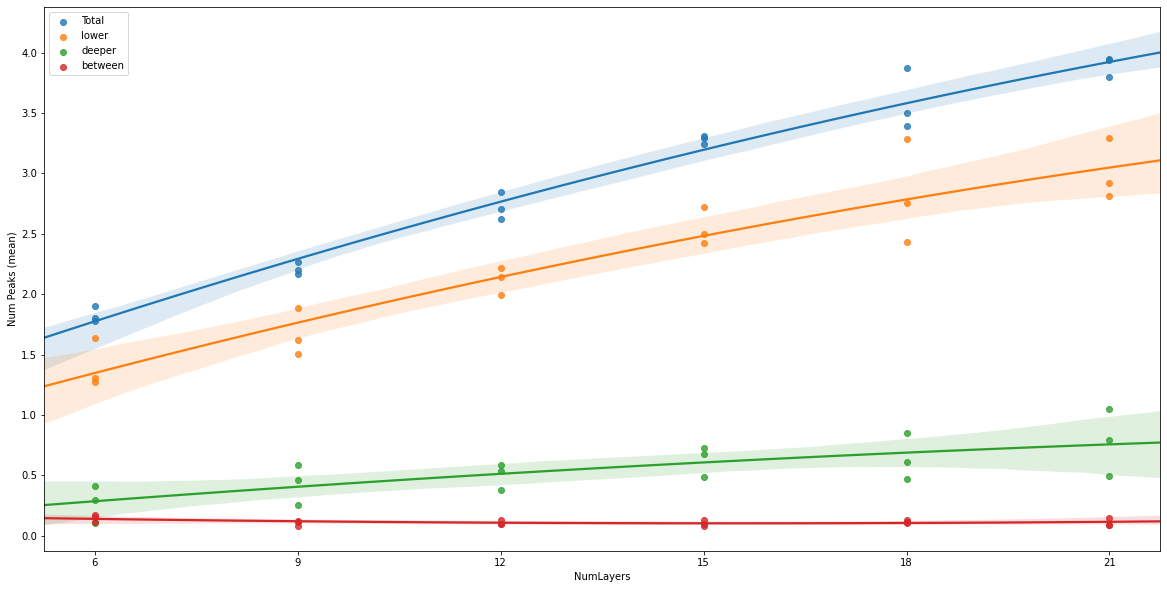

TargetLayer Peaks_Total                                      Peaks_lower  \
                       sum count      mean       std        var         sum   
0            1        4062  1242  3.270531  4.270007  18.232958        2100   
1            2         922   414  2.227053  1.653126   2.732826         579   
2            3        1004   414  2.425121  2.851098   8.128762         735   
3            4        1080   414  2.608696  2.714239   7.367091         782   
4            5        2577   828  3.112319  3.716129  13.809618        1873   
5            6         617   207  2.980676  2.064403   4.261761         525   
6            7         357   207  1.724638  1.470262   2.161672         354   
7            8        1060   414  2.560386  2.311143   5.341381         970   
8            9        1285   414  3.103865  2.660142   7.076353        1153   
9           11        1930   621  3.107890  2.766671   7.654470        1762   
10          14        1202   414  2.903382  3.372778  11.375630        1186   
11          16         756   207  3.652174  3.512085  12.334740         743   
12          17         655   207  3.164251  4.476701  20.040852         647   
13          20         638   207  3.082126  3.332398  11.104873         636   

                              ... Peaks_deeper                            \
   count      mean       std  ...          sum count      mean       std   
0   1242  1.690821  2.797673  ...         1754  1242  1.412238  2.438764   
1    414  1.398551  1.101660  ...          256   414  0.618357  1.188831   
2    414  1.775362  2.580476  ...          194   414  0.468599  1.110256   
3    414  1.888889  2.258634  ...          250   414  0.603865  1.371655   
4    828  2.262077  3.073491  ...          570   828  0.688406  1.480877   
5    207  2.536232  1.871449  ...           54   207  0.260870  0.892017   
6    207  1.710145  1.452498  ...            0   207  0.000000  0.000000   
7    414  2.342995  2.204604  ...           61   414  0.147343  0.726550   
8    414  2.785024  2.625940  ...           90   414  0.217391  0.821082   
9    621  2.837359  2.650190  ...          120   621  0.193237  0.769176   
10   414  2.864734  3.320793  ...           11   414  0.026570  0.447505   
11   207  3.589372  3.537659  ...            6   207  0.028986  0.218402   
12   207  3.125604  4.451865  ...            8   207  0.038647  0.556038   
13   207  3.072464  3.335535  ...            2   207  0.009662  0.139010   

             Peaks_between                                      
         var           sum count      mean       std       var  
0   5.947570           208  1242  0.167472  0.516579  0.266854  
1   1.413318            87   414  0.210145  0.553915  0.306822  
2   1.232668            75   414  0.181159  0.568361  0.323034  
3   1.881438            48   414  0.115942  0.412970  0.170544  
4   2.192997           134   828  0.161836  0.614530  0.377647  
5   0.795694            38   207  0.183575  0.642447  0.412739  
6   0.000000             3   207  0.014493  0.119800  0.014352  
7   0.527874            29   414  0.070048  0.344337  0.118568  
8   0.674176            42   414  0.101449  0.398967  0.159175  
9   0.591632            48   621  0.077295  0.398161  0.158532  
10  0.200261             5   414  0.012077  0.147124  0.021646  
11  0.047699             7   207  0.033816  0.206253  0.042540  
12  0.309179             0   207  0.000000  0.000000  0.000000  
13  0.019324             0   207  0.000000  0.000000  0.000000  

[14 rows x 21 columns]

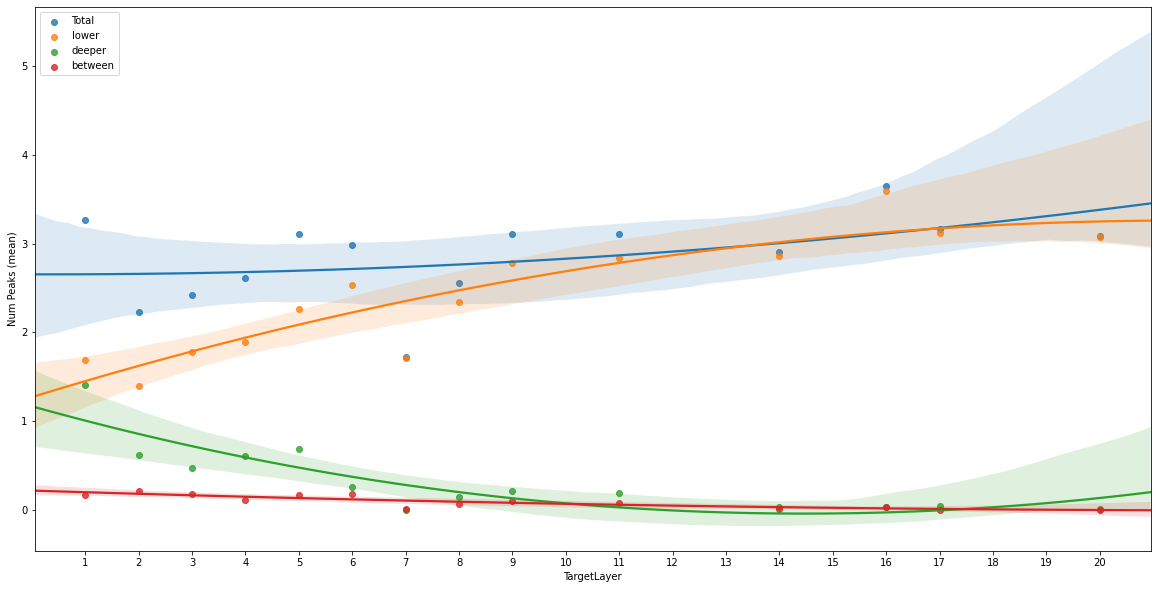

TargetDepth Peaks_Total                                      Peaks_lower  \
                       sum count      mean       std        var         sum   
0     -0.96995         265    69  3.840580  3.950514  15.606564         265   
1     -0.96485         249    69  3.608696  5.151292  26.535806         249   
2     -0.95770         186    69  2.695652  2.647442   7.008951         186   
3     -0.95240         185    69  2.681159  3.070221   9.426257         185   
4     -0.94690         167    69  2.420290  2.212304   4.894288         167   
..         ...         ...   ...       ...       ...        ...         ...   
82    -0.02930         192    69  2.782609  3.289330  10.819693         104   
83    -0.01820         187    69  2.710145  2.941095   8.650043          99   
84    -0.01255         292    69  4.231884  6.879520  47.327792         196   
85    -0.00925         275    69  3.985507  6.309407  39.808610         155   
86    -0.00715         326    69  4.724638  7.294002  53.202472         177   

                              ... Peaks_deeper                            \
   count      mean       std  ...          sum count      mean       std   
0     69  3.840580  3.950514  ...            0    69  0.000000  0.000000   
1     69  3.608696  5.151292  ...            0    69  0.000000  0.000000   
2     69  2.695652  2.647442  ...            0    69  0.000000  0.000000   
3     69  2.681159  3.070221  ...            0    69  0.000000  0.000000   
4     69  2.420290  2.212304  ...            0    69  0.000000  0.000000   
..   ...       ...       ...  ...          ...   ...       ...       ...   
82    69  1.507246  2.153132  ...           78    69  1.130435  2.064497   
83    69  1.434783  2.271811  ...           82    69  1.188406  1.638466   
84    69  2.840580  5.927561  ...           94    69  1.362319  2.319806   
85    69  2.246377  3.687841  ...          110    69  1.594203  3.711345   
86    69  2.565217  5.111919  ...          145    69  2.101449  3.434877   

              Peaks_between                                      
          var           sum count      mean       std       var  
0    0.000000             0    69  0.000000  0.000000  0.000000  
1    0.000000             0    69  0.000000  0.000000  0.000000  
2    0.000000             0    69  0.000000  0.000000  0.000000  
3    0.000000             0    69  0.000000  0.000000  0.000000  
4    0.000000             0    69  0.000000  0.000000  0.000000  
..        ...           ...   ...       ...       ...       ...  
82   4.262148            10    69  0.144928  0.462581  0.213981  
83   2.684569             6    69  0.086957  0.283836  0.080563  
84   5.381500             2    69  0.028986  0.240772  0.057971  
85  13.774084            10    69  0.144928  0.862202  0.743393  
86  11.798380             4    69  0.057971  0.291248  0.084825  

[87 rows x 21 columns]

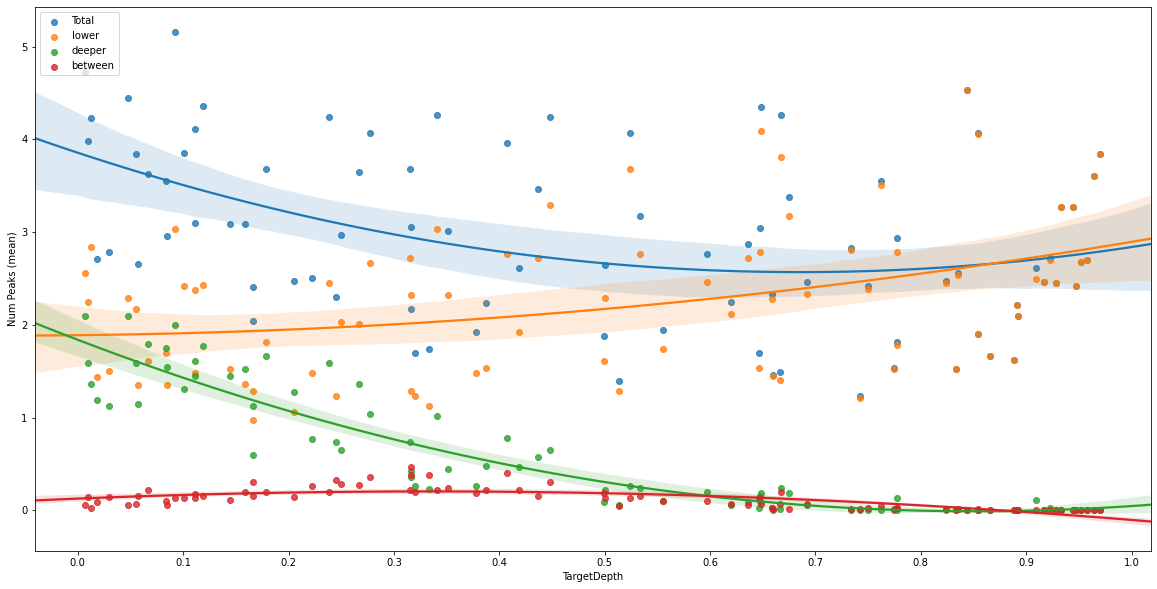

TargetLayer_Relative Peaks_Total                                       \
                                sum count      mean       std        var   
0              0.047619         846   207  4.086957  6.485396  42.060363   
1              0.055556         753   207  3.637681  4.685148  21.950612   
2              0.066667         796   207  3.845411  4.739348  22.461423   
3              0.083333         603   207  2.913043  2.948123   8.691431   
4              0.111111         565   207  2.729469  2.566447   6.586652   
5              0.166667         499   207  2.410628  2.405593   5.786877   
6              0.222222         531   207  2.565217  1.870659   3.499367   
7              0.238095         922   207  4.454106  5.062385  25.627738   
8              0.250000         651   207  3.144928  3.618757  13.095399   
9              0.266667         775   207  3.743961  2.965358   8.793349   
10             0.277778         875   207  4.227053  3.948902  15.593828   
11             0.333333         391   207  1.888889  1.322774   1.749730   
12             0.500000        1756   621  2.827697  2.423196   5.871877   
13             0.523810         869   207  4.198068  3.492627  12.198443   
14             0.533333         660   207  3.188406  2.229167   4.969185   
15             0.555556         437   207  2.111111  1.616728   2.613808   
16             0.666667         305   207  1.473430  1.840225   3.386427   
17             0.733333         609   207  2.942029  2.117088   4.482060   
18             0.750000         499   207  2.410628  2.050452   4.204353   
19             0.761905         756   207  3.652174  3.512085  12.334740   
20             0.777778        1002   414  2.420290  2.283147   5.212759   
21             0.833333         343   207  1.657005  2.326136   5.410909   
22             0.888889         400   207  1.932367  2.224154   4.946860   
23             0.916667         452   207  2.183575  2.068046   4.276816   
24             0.933333         557   207  2.690821  3.924167  15.399090   
25             0.944444         655   207  3.164251  4.476701  20.040852   
26             0.952381         638   207  3.082126  3.332398  11.104873   

   Peaks_lower                            ... Peaks_deeper                  \
           sum count      mean       std  ...          sum count      mean   
0          440   207  2.125604  3.905892  ...          390   207  1.884058   
1          399   207  1.927536  3.048088  ...          325   207  1.570048   
2          432   207  2.086957  3.744533  ...          333   207  1.608696   
3          289   207  1.396135  2.025944  ...          291   207  1.405797   
4          291   207  1.405797  1.627902  ...          229   207  1.106280   
5          249   207  1.202899  1.008407  ...          186   207  0.898551   
6          301   207  1.454106  1.248910  ...          193   207  0.932367   
7          569   207  2.748792  4.163490  ...          302   207  1.458937   
8          440   207  2.125604  3.366550  ...          167   207  0.806763   
9          491   207  2.371981  2.550802  ...          245   207  1.183575   
10         579   207  2.797101  3.451100  ...          239   207  1.154589   
11         278   207  1.342995  0.931247  ...           63   207  0.304348   
12        1487   621  2.394525  2.323908  ...          166   621  0.267311   
13         726   207  3.507246  3.388830  ...          105   207  0.507246   
14         570   207  2.753623  2.111497  ...           61   207  0.294686   
15         383   207  1.850242  1.481860  ...           29   207  0.140097   
16         291   207  1.405797  1.803332  ...            5   207  0.024155   
17         584   207  2.821256  2.120618  ...           15   207  0.072464   
18         486   207  2.347826  2.027668  ...            5   207  0.024155   
19         743   207  3.589372  3.537659  ...            6   207  0.028986   
20         983   414  2.374396  2.193413  ...           11   414  0.026570   
21  

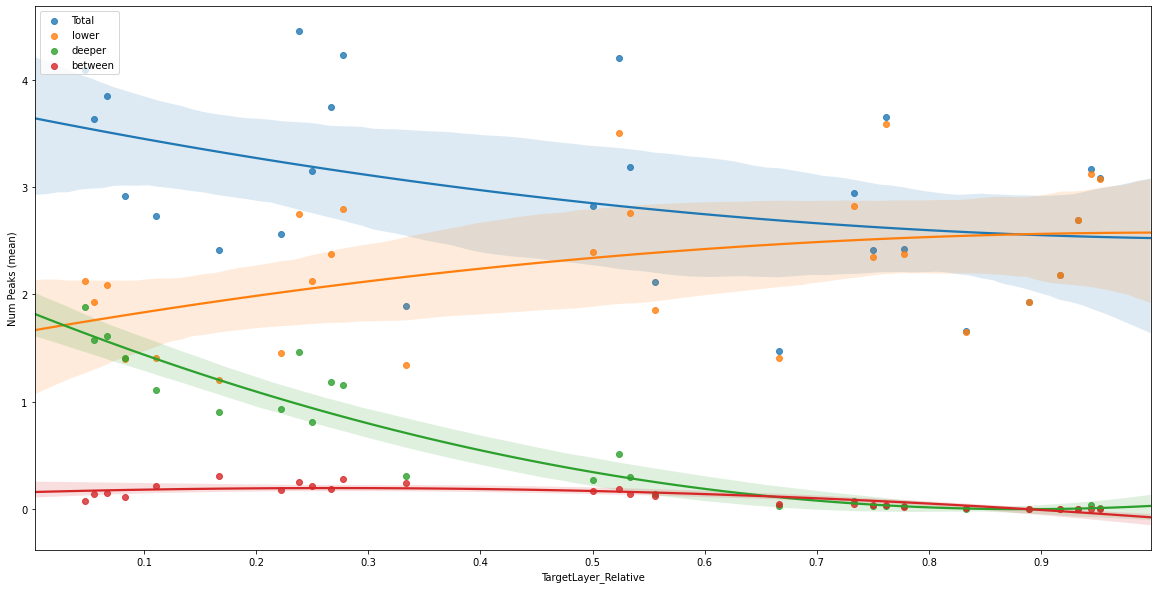

In [69]:
peaks = loadPeaks()

# group by layers only
grouped_layers = peaks.groupby(["NumLayers"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean", "std", "var"]).reset_index()

display(grouped_layers)

fig_layers = plt.figure(figsize=(20,10))

ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_Total"]["mean"], truncate=False, label='Total')
ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_lower"]["mean"], truncate=False, label='lower')
ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_deeper"]["mean"], truncate=False, label='deeper')
ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_between"]["mean"], truncate=False, label='between')

ax_layers.xaxis.set_major_locator(MultipleLocator(3))
ax_layers.set_ylabel('Num Peaks (mean)')

ax_layers.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_layer.png')
plt.show()

# group by layers + mapping
grouped_mapping = peaks.groupby(["MappingMethod", "NumLayers"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean", "std", "var"]).reset_index()

display(grouped_mapping)

fig_mapping = plt.figure(figsize=(20,10))

ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_Total"]["mean"], order=2, truncate=False, label='Total')
ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_lower"]["mean"], order=2, truncate=False, label='lower')
ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_deeper"]["mean"], order=2, truncate=False, label='deeper')
ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_between"]["mean"], order=2, truncate=False, label='between')

ax_mapping.xaxis.set_major_locator(MultipleLocator(3))
ax_mapping.set_ylabel('Num Peaks (mean)')

ax_mapping.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_layer_mapping.png')
plt.show()

# group by target Layer
grouped_targetLayer = peaks.groupby(["TargetLayer"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean", "std", "var"]).reset_index()

display(grouped_targetLayer)

fig_targetLayer = plt.figure(figsize=(20,10))

ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_Total"]["mean"], order=2, truncate=False, label='Total')
ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_lower"]["mean"], order=2, truncate=False, label='lower')
ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_deeper"]["mean"], order=2, truncate=False, label='deeper')
ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_between"]["mean"], order=2, truncate=False, label='between')

ax_targetLayer.xaxis.set_major_locator(MultipleLocator(1))
ax_targetLayer.set_ylabel('Num Peaks (mean)')

ax_targetLayer.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_targetLayer.png')
plt.show()

# group by target depth (middle of target layer)
grouped_targetDepth = peaks.groupby(["TargetDepth"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean", "std", "var"]).reset_index()

display(grouped_targetDepth)

fig_targetDepth = plt.figure(figsize=(20,10))

ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_Total"]["mean"], order=2, truncate=False, label='Total')
ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_lower"]["mean"], order=2, truncate=False, label='lower')
ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_deeper"]["mean"], order=2, truncate=False, label='deeper')
ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_between"]["mean"], order=2, truncate=False, label='between')

ax_targetDepth.xaxis.set_major_locator(MultipleLocator(0.1))
ax_targetDepth.set_ylabel('Num Peaks (mean)')

ax_targetDepth.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_targetDepth.png')
plt.show()


# group by relative target 

grouped_targetRelative = peaks.groupby(["TargetLayer_Relative"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean", "std", "var"]).reset_index()

display(grouped_targetRelative)

fig_targetRelative = plt.figure(figsize=(20,10))

ax_targetRelative = sns.regplot(x=grouped_targetRelative["TargetLayer_Relative"], y=grouped_targetRelative["Peaks_Total"]["mean"], order=2, truncate=False, label='Total')
ax_targetRelative = sns.regplot(x=grouped_targetRelative["TargetLayer_Relative"], y=grouped_targetRelative["Peaks_lower"]["mean"], order=2, truncate=False, label='lower')
ax_targetRelative = sns.regplot(x=grouped_targetRelative["TargetLayer_Relative"], y=grouped_targetRelative["Peaks_deeper"]["mean"], order=2, truncate=False, label='deeper')
ax_targetRelative = sns.regplot(x=grouped_targetRelative["TargetLayer_Relative"], y=grouped_targetRelative["Peaks_between"]["mean"], order=2, truncate=False, label='between')

ax_targetRelative.xaxis.set_major_locator(MultipleLocator(0.1))
ax_targetRelative.set_ylabel('Num Peaks (mean)')

ax_targetRelative.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_targetRelative.png')
plt.show()


---
## Draw distribution of depth layers

for validation / checking that depth layer conditions were equally distributed

---

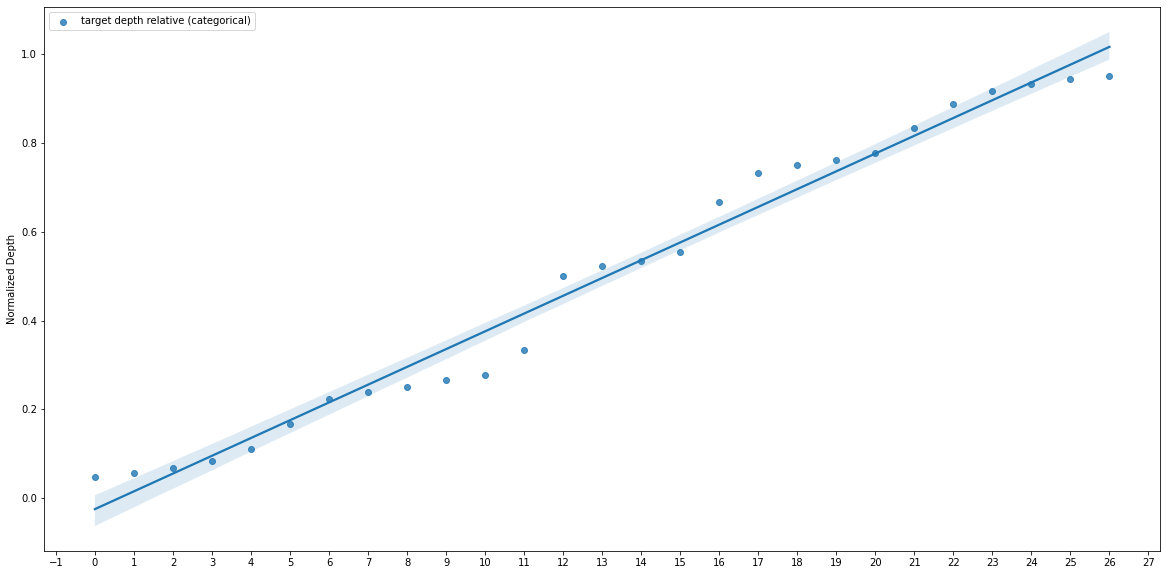

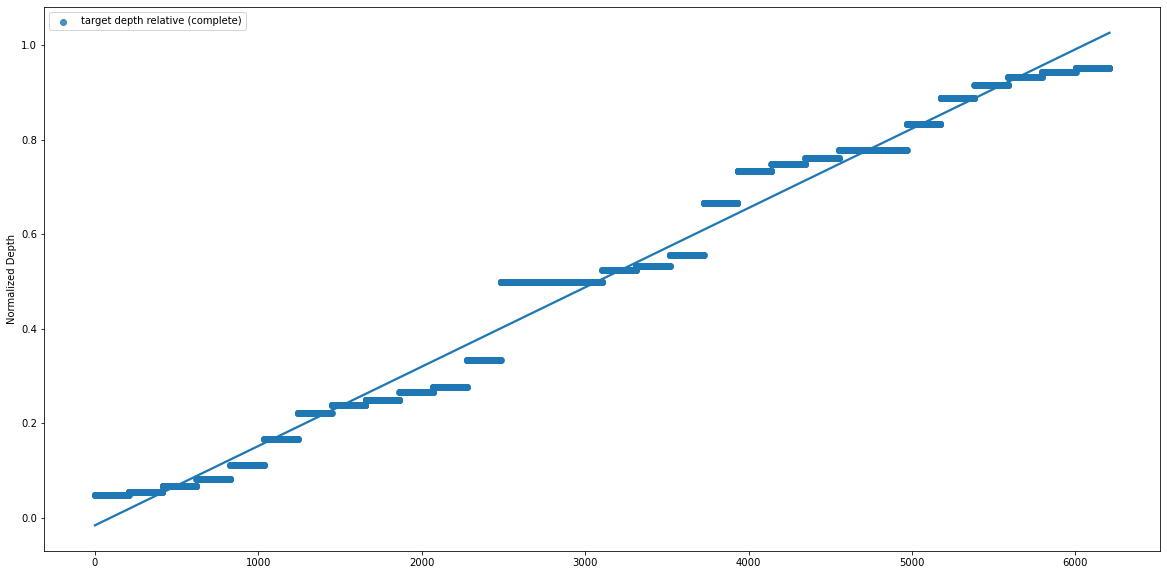

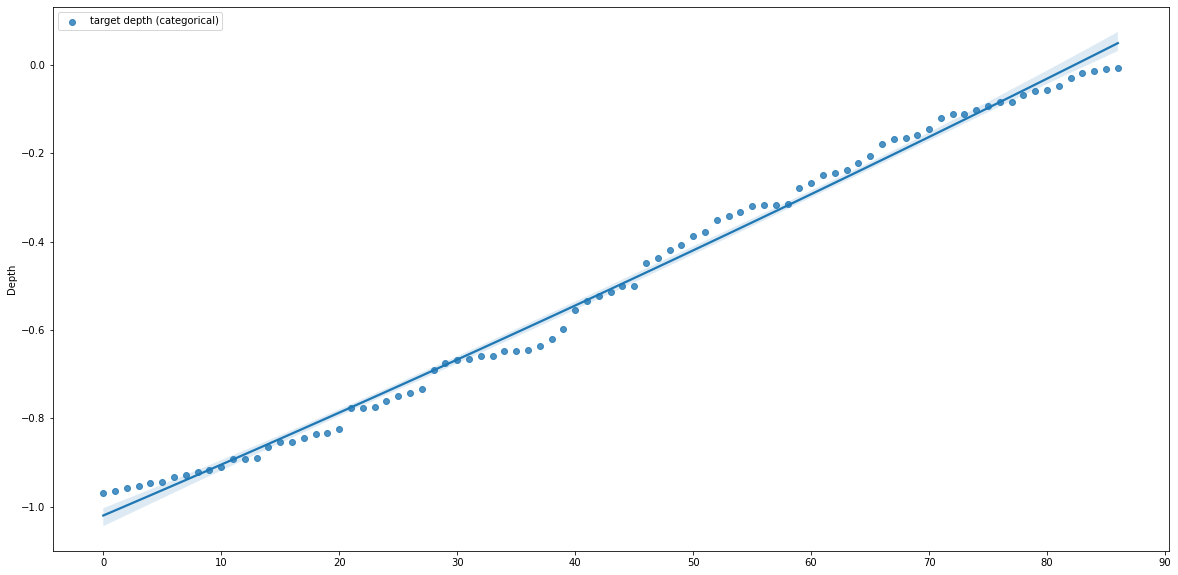

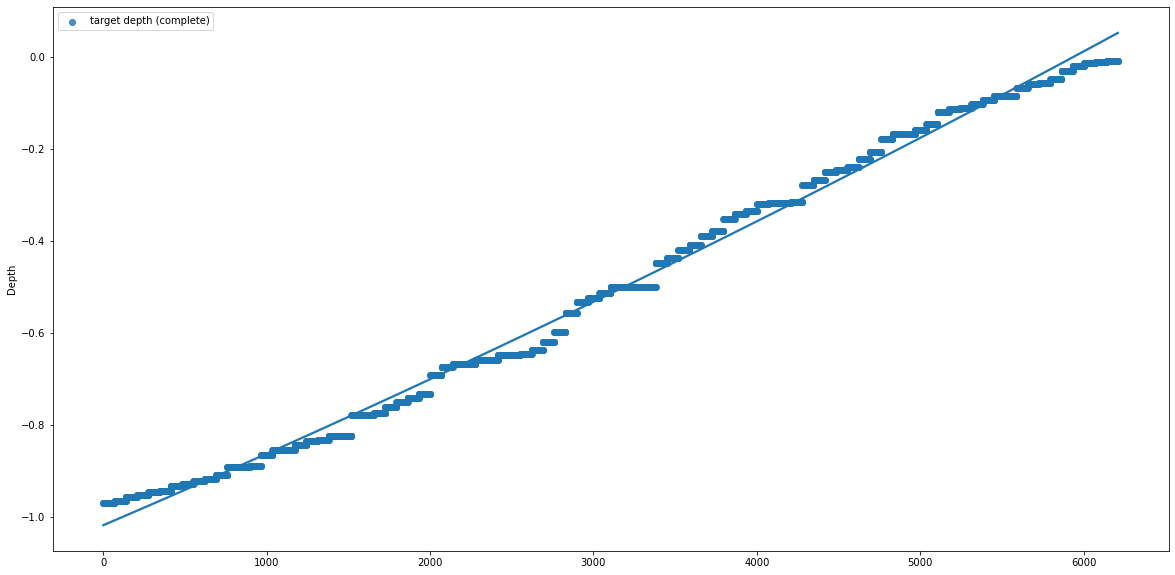

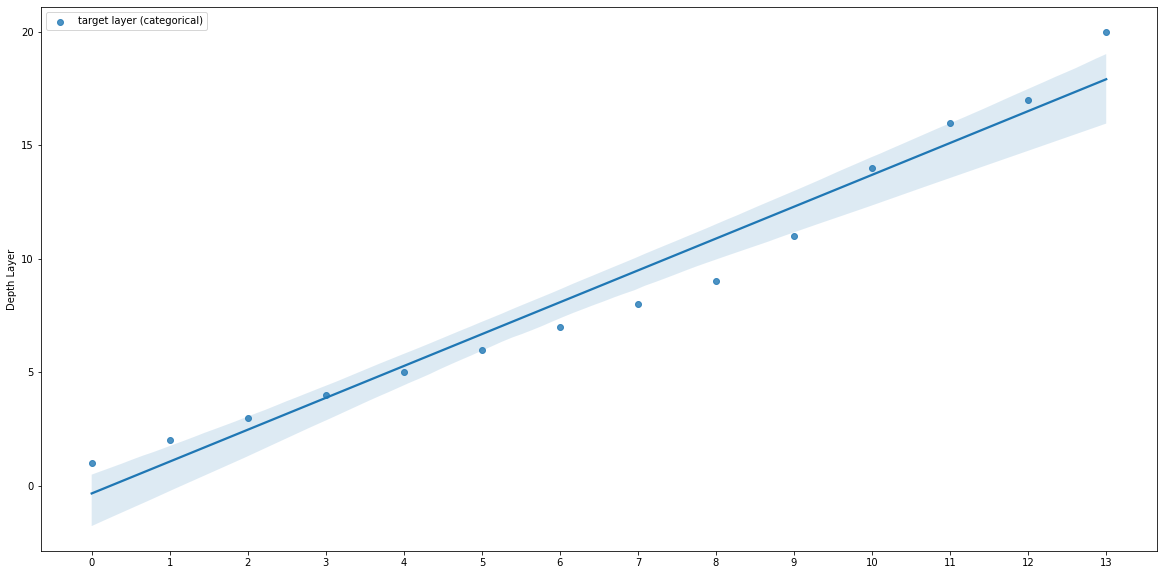

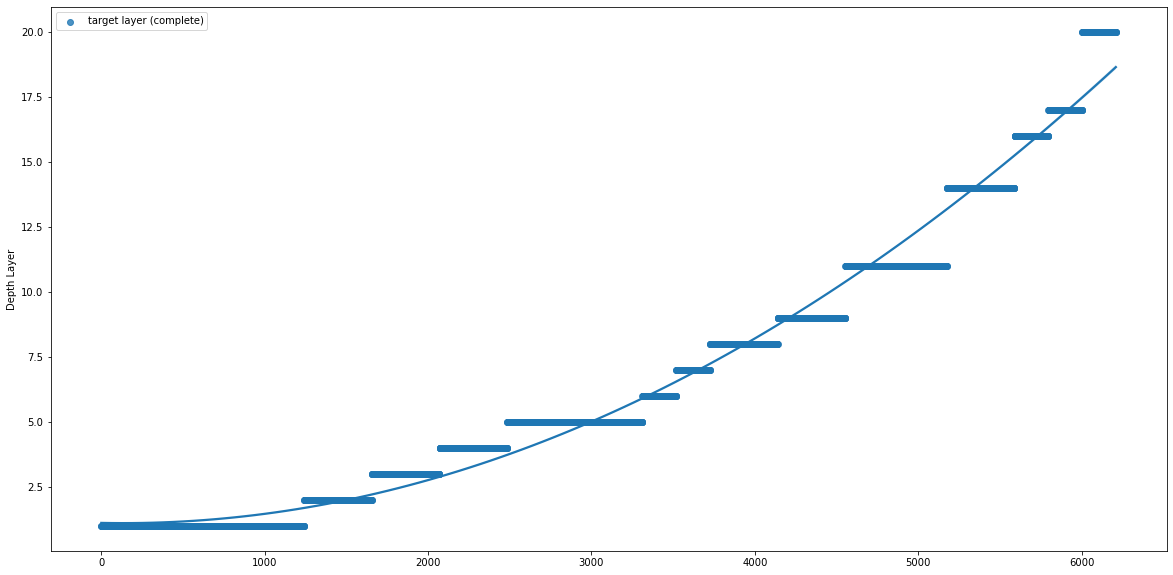

In [94]:
# draw the normalized depth (categorical distribution)
targets_rel = peaks["TargetLayer_Relative"].drop_duplicates().sort_values().reset_index()

fig_rel = plt.figure(figsize=(20,10))

ax_rel = sns.regplot(x=targets_rel.index, y=targets_rel["TargetLayer_Relative"], label="target depth relative (categorical)")

ax_rel.xaxis.set_major_locator(MultipleLocator(1))
ax_rel.set_ylabel('Normalized Depth')

ax_rel.legend(loc='upper left')

plt.savefig(rf'{export_img}distribution_depth_relative.png')

plt.show()


# draw the normalized depth (complete distribution)
targets_rel_all = peaks["TargetLayer_Relative"].sort_values().reset_index()

fig_rel_all = plt.figure(figsize=(20,10))

ax_rel_all = sns.regplot(x=targets_rel_all.index, y=targets_rel_all["TargetLayer_Relative"], label="target depth relative (complete)")

ax_rel_all.set_ylabel('Normalized Depth')

ax_rel_all.legend(loc='upper left')

plt.savefig(rf'{export_img}distribution_depth_relative_all.png')

plt.show()

# draw the depth (categorical distribution)
targets_depth = peaks["TargetDepth"].drop_duplicates().sort_values().reset_index()

fig_depth = plt.figure(figsize=(20,10))

ax_depth = sns.regplot(x=targets_depth.index, y=targets_depth["TargetDepth"], label="target depth (categorical)", order=2)

ax_depth.xaxis.set_major_locator(MultipleLocator(10))
ax_depth.set_ylabel('Depth')

ax_depth.legend(loc='upper left')

plt.savefig(rf'{export_img}distribution_depth.png')

plt.show()

# draw the depth (complete distribution)
targets_depth_all = peaks["TargetDepth"].sort_values().reset_index()

fig_depth_all = plt.figure(figsize=(20,10))

ax_depth_all = sns.regplot(x=targets_depth_all.index, y=targets_depth_all["TargetDepth"], label="target depth (complete)", order=2)

ax_depth_all.set_ylabel('Depth')

ax_depth_all.legend(loc='upper left')

plt.savefig(rf'{export_img}distribution_depth_all.png')

plt.show()

# draw the target layer (categorical distribution)
targets_layer = peaks["TargetLayer"].drop_duplicates().sort_values().reset_index()

fig_layer = plt.figure(figsize=(20,10))

ax_layer = sns.regplot(x=targets_layer.index, y=targets_layer["TargetLayer"], label="target layer (categorical)")

ax_layer.xaxis.set_major_locator(MultipleLocator(1))
ax_layer.set_ylabel('Depth Layer')

ax_layer.legend(loc='upper left')

plt.savefig(rf'{export_img}distribution_target_layer.png')

plt.show()

# draw the target layer (complete distribution)
targets_layer_all = peaks["TargetLayer"].sort_values().reset_index()

fig_layer_all = plt.figure(figsize=(20,10))

ax_layer_all = sns.regplot(x=targets_layer_all.index, y=targets_layer_all["TargetLayer"], label="target layer (complete)", order=2)

ax_layer_all.set_ylabel('Depth Layer')

ax_layer_all.legend(loc='upper left')

plt.savefig(rf'{export_img}distribution_target_layer_all.png')

plt.show()


--- 
## Extraction: Duration of "TERMINATED" Trials

| PROBAND | BLOCK | TASK | TRIAL | DATE_START               | DATE_HOLD                | DATE_TERMINATED          | DURATION | NUM_LAYERS | TARGET_LAYER | MAPPING_METHOD |
| ------- | ----- | ---- | ----- | ------------------------ | ------------------------ | ------------------------ | -------- | ---------- | ------------ | -------------- |
| 1       | 1     | 1    | 0     | 2021-05-10T12:13:56.584Z | 2021-05-10T12:15:56.584Z | 2021-05-10T12:16:46.584Z | 0:50     | 6          | 1            |  densening     | 

---

In [145]:
def extractHold(probandId, blockNo, taskNo, trialNo, posX, terminated):

    date = df_cleaned[(df_cleaned["Proband"] == probandId) & (df_cleaned["Block"] == blockNo) &(df_cleaned["Task"] == taskNo) & (df_cleaned["Trial"] == trialNo) & (df_cleaned["posX"] == posX)] 

    if len(date) == 0:
        return terminated

    return date['DateTime'].iat[0]

df_cleaned = pd.read_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep=";")

terminated_results = df_cleaned[df_cleaned["posX"] == ' TERMINATED']

result = pd.DataFrame()
result['Proband'] = terminated_results['Proband']
result['Block'] = terminated_results['Block']
result['Task'] = terminated_results['Task']
result['Trial'] = terminated_results['Trial']
result['Proband'] = terminated_results['Proband']
result['Date_Hold'] = [extractHold(row[0], row[1], row[2], row[3], ' HOLD', row[4]) for row in zip(terminated_results['Proband'], terminated_results['Block'], terminated_results['Task'], terminated_results['Trial'], terminated_results['DateTime'])]
result['Date_Start'] = [extractHold(row[0], row[1], row[2], row[3], ' START', row[4]) for row in zip(terminated_results['Proband'], terminated_results['Block'], terminated_results['Task'], terminated_results['Trial'], terminated_results['DateTime'])]
result['Date_Terminated'] = terminated_results['DateTime']
result["Duration"] = (pd.to_datetime(result["Date_Terminated"], format=timeFormat) - pd.to_datetime(result["Date_Hold"], format=timeFormat)).dt.total_seconds()
result['Num_Layers'] = terminated_results['NumLayers']
result['MappingMethod'] = terminated_results['mappingMethod']
result['Target_Layer'] = terminated_results['Target']

display(result)

result.to_csv(rf'{export}Duration_terminatedTrials.csv', sep= ";")


,Proband,Block,Task,Trial,Date_Hold,Date_Start,Date_Terminated,Duration,Num_Layers,MappingMethod,Target_Layer
314,1,1,1,1,2021-05-10T12:14:11.430Z,2021-05-10T12:14:07.072Z,2021-05-10T12:14:11.486Z,0.056,6,direct,5
616,1,1,1,3,2021-05-10T12:14:27.401Z,2021-05-10T12:14:23.822Z,2021-05-10T12:14:27.449Z,0.048,6,direct,1
1478,1,1,2,2,2021-05-10T12:15:09.323Z,2021-05-10T12:14:56.801Z,2021-05-10T12:15:10.351Z,1.028,9,direct,1
2047,1,1,2,4,2021-05-10T12:15:34.882Z,2021-05-10T12:15:25.129Z,2021-05-10T12:15:34.961Z,0.079,9,direct,2
2801,1,1,3,3,2021-05-10T12:16:12.161Z,2021-05-10T12:16:07.989Z,2021-05-10T12:16:12.383Z,0.222,9,direct,8
...,...,...,...,...,...,...,...,...,...,...,...
1531983,24,3,15,1,2021-06-30T12:34:33.433Z,2021-06-30T12:34:29.024Z,2021-06-30T12:34:34.443Z,1.010,12,widening,1
1533647,24,3,16,4,2021-06-30T12:35:52.941Z,2021-06-30T12:35:48.779Z,2021-06-30T12:35:54.102Z,1.161,12,widening,1
1534276,24,3,17,2,2021-06-30T12:36:24.958Z,2021-06-30T12:36:21.343Z,2021-06-30T12:36:25.831Z,0.873,21,widening,5
1534391,24,3,17,3,2021-06-30T12:36:31.230Z,2021-06-30T12:36:27.045Z,2021-06-30T12:36:31.445Z,0.215,21,widening,1


---
## Draw Durations
---

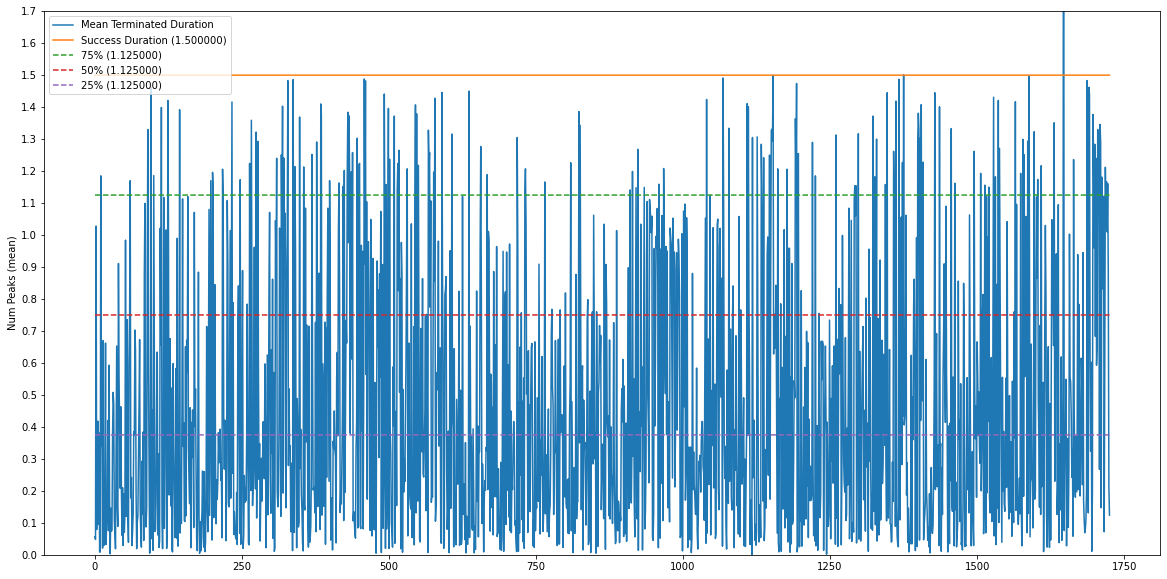

Num_Layers MappingMethod Duration                                    
                                 sum count      mean       std       var
0           6     densening   37.189    88  0.422602  0.336480  0.113219
1           6        direct   31.504    91  0.346198  0.354084  0.125375
2           6      widening   35.775   104  0.343990  0.357886  0.128082
3           9     densening   28.285    64  0.441953  0.438646  0.192410
4           9        direct   24.873    65  0.382662  0.405282  0.164253
5           9      widening   54.819   116  0.472578  0.435635  0.189778
6          12     densening   29.558    82  0.360463  0.318443  0.101406
7          12        direct   41.152    84  0.489905  0.436377  0.190425
8          12      widening   67.569   121  0.558421  0.433657  0.188058
9          15     densening   41.536    82  0.506537  0.465591  0.216775
10         15        direct   39.530    84  0.470595  0.418291  0.174967
11         15      widening   63.928   126  0.507365  0.401790  0.161435
12         18     densening   35.477    78  0.454833  0.368480  0.135777
13         18        direct   48.660    96  0.506875  0.444007  0.197142
14         18      widening   61.856   127  0.487055  0.402710  0.162176
15         21     densening   45.730   101  0.452772  0.387192  0.149917
16         21        direct   48.534    94  0.516319  0.430041  0.184936
17         21      widening   59.293   123  0.482057  0.379598  0.144095

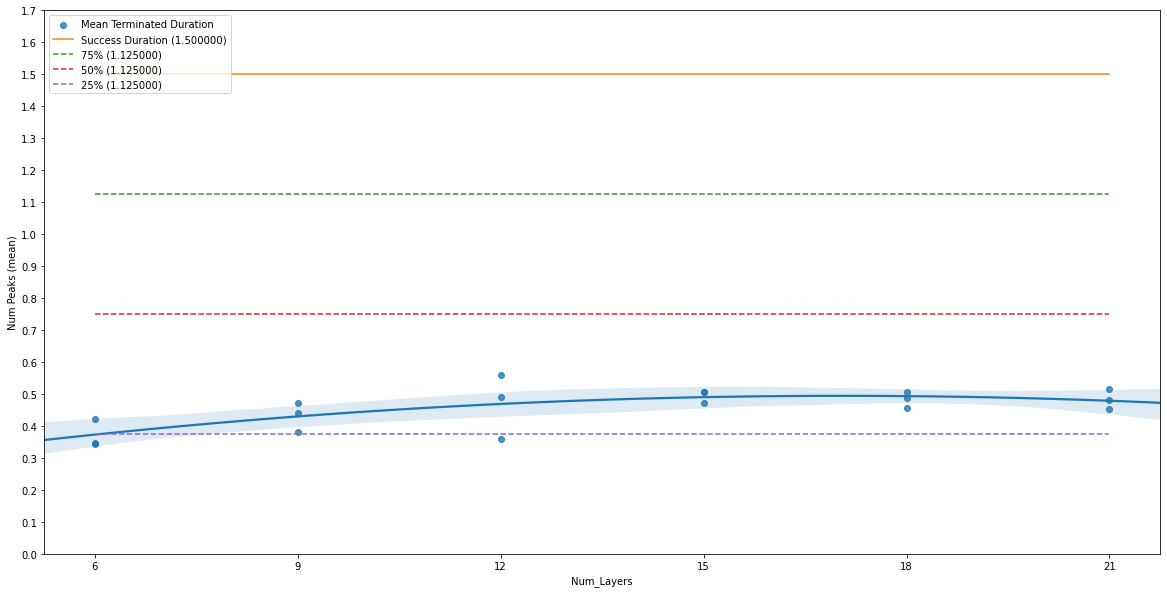

In [163]:
terminated_durations = pd.read_csv(rf'{export}Duration_terminatedTrials.csv', sep= ";")

ymax = 1.7
dwell_time = 1.5
hlines = [['75%', 0.75*dwell_time], ['50%', 0.5*dwell_time], ['25%', 0.25*dwell_time]]
# show all 

default = [dwell_time]*len(terminated_durations) 

fig_complete, ax_complete = plt.subplots(figsize=(20,10))

ax_complete.plot(terminated_durations.index, terminated_durations["Duration"], label='Mean Terminated Duration')
ax_complete.plot(terminated_durations.index, default, label=f'Success Duration ({format(default[0],"f")})', linestyle='-')

for h in hlines:
    ax_complete.plot(terminated_durations.index, [h[1]] * len(terminated_durations), label=f'{h[0]} ({format(h1[0],"f")})', linestyle='--')    

ax_complete.yaxis.set_major_locator(MultipleLocator(0.1))
ax_complete.set_ylabel('Num Peaks (mean)')

ax_complete.set_ylim([0, ymax])

ax_complete.legend(loc='upper left')

plt.savefig(rf'{export_img}terminated_durations.png')
plt.show()

# group by layers only
grouped_layers = terminated_durations.groupby(["Num_Layers", "MappingMethod"])[["Duration"]].agg(["sum", "count", "mean", "std", "var"]).reset_index()

display(grouped_layers)

default = [dwell_time]*len(grouped_layers) 

fig_layers = plt.figure(figsize=(20,10))

ax_layers = sns.regplot(x=grouped_layers["Num_Layers"], y=grouped_layers["Duration"]["mean"], order=2, truncate=False, label='Mean Terminated Duration')
ax_layers.plot(grouped_layers["Num_Layers"], default, label=f'Success Duration ({format(default[0],"f")})', linestyle='-')
for h in hlines:
    ax_layers.plot(grouped_layers["Num_Layers"], [h[1]] * len(grouped_layers), label=f'{h[0]} ({format(h1[0],"f")})', linestyle='--') 

ax_layers.xaxis.set_major_locator(MultipleLocator(3))
ax_layers.yaxis.set_major_locator(MultipleLocator(0.1))
ax_layers.set_ylabel('Num Peaks (mean)')

ax_layers.set_ylim([0, ymax])

ax_layers.legend(loc='upper left')

plt.savefig(rf'{export_img}terminated_durations_layers.png')
plt.show()